In [1]:
import networkx
from itertools import combinations

In [2]:
# Takes a list lin_ext of lists (linear extensions)
# Returns a list of elements and a list of relations that defines the
# poset obtained by intersecting the linear extensions of lin_ext
# To obtain such order, one has to compute Poset(poset_from_linear_extensions(L))

def poset_from_linear_extensions(lin_ext):
    # Build the based set
    elements = set()
    for ext in lin_ext:
        elements.update(ext)
    
    elements = sorted(elements)
    
    # Build the set of relations from the linear extensions in L
    order_relation = set()
    for ext in lin_ext:
        for i in range(len(ext)):
            for j in range(i + 1, len(ext)):
                order_relation.add((ext[i], ext[j]))
    
    # Verify that the relations are satisfied by all linear extensions in L
    common_relations = set(order_relation)
    for (a, b) in order_relation:
        for ext in lin_ext:
            if not (ext.index(a) < ext.index(b)):
                common_relations.discard((a, b))
                break
    
    return elements, common_relations

In [3]:
# Input: a unicycle poset
# Output: a list of the trees grafted to the extremal vertices and the covers of the fundamental cycle of the poset.
# The list starts with the trees attached to the bottom elements followed by the trees attached to the top elements
# and finishes with the trees on the covers
def cycle_and_attached_trees(poset):

    # Undirected version of the Hasse diagram
    cover_graph = poset.hasse_diagram().to_undirected()

    # Find all cycles
    cycles = cover_graph.cycle_basis()

    # Verify that there is a unique cycle
    if len(cycles) != 1:
        raise ValueError("The graph does not have exactly one cycle.")

    # Extract the cycle
    cycle = cycles[0]

    # Find all maxs and mins of the cycle
    cycle_poset = poset.subposet(cycle)
    cycle_top_elements = cycle_poset.maximal_elements()
    cycle_bottom_elements = cycle_poset.minimal_elements()

    # Three cases, if the underlying cycle has a top and a bottom element, has 2 bottom and 2 top elements or has more
    # Order all the bottom elements, top elements and the elements in between
    if len(cycle_bottom_elements) == 1:
        while cycle[0] not in cycle_bottom_elements:
            cycle.append(cycle.pop(0))
        k = cycle.index(cycle_top_elements[0])
        cyclic_list = [cycle[0],cycle[0:k+1],cycle[k], [cycle[0]] + list(reversed(cycle[k:]))]
    
    elif len(cycle_bottom_elements) == 2:
        cyclic_list = []
        for i in range(len(cycle_bottom_elements)):
            cyclic_list = cyclic_list + [cycle_bottom_elements[i], poset.closed_interval(cycle_bottom_elements[i], cycle_top_elements[i]),cycle_top_elements[i], poset.closed_interval(cycle_bottom_elements[(i+1) % len(cycle_bottom_elements)], cycle_top_elements[i])]
    
    elif len(cycle_bottom_elements) > 2:
        k = 0
        while k < len(cycle_bottom_elements)-1:
            if poset.join(cycle_bottom_elements[k],cycle_bottom_elements[k+1]) == None:
                cycle_bottom_elements = cycle_bottom_elements.append(cycle_bottom_elements.pop(k+1))
            else:
                k = k+1

        cyclic_list=[]
        for i in range(len(cycle_bottom_elements)):
            cyclic_list = cyclic_list + [cycle_bottom_elements[i], poset.closed_interval(cycle_bottom_elements[i], poset.join(cycle_bottom_elements[i],cycle_bottom_elements[(i+1) % len(cycle_bottom_elements)])), poset.join(cycle_bottom_elements[i],cycle_bottom_elements[(i+1) % len(cycle_bottom_elements)]), poset.closed_interval(cycle_bottom_elements[(i+1) % len(cycle_bottom_elements)], poset.join(cycle_bottom_elements[i],cycle_bottom_elements[(i+1) % len(cycle_bottom_elements)]))]
    
    # Build the cycle edges
    cycle_edges = []
    n = len(cycle)
    for i in range(n):
        u = cycle[i]
        v = cycle[(i + 1) % n]
        cycle_edges.append((u, v))

    # Remove cycle edges
    forest = cover_graph.copy()
    forest.delete_edges(cycle_edges)

    # Extract all the tree posets that are "attached" to the bottom elements, the top elements and in between top and bottom elements
    attached_trees = []
    
    # Tree posets for bottom elements
    for i in range(len(cyclic_list)/4):
        comp = forest.connected_component_containing_vertex(cyclic_list[4*i])
        attached_trees = attached_trees + [[poset.subposet(comp),cyclic_list[4*i]]]   
    
    # Tree posets for top elements
    for i in range(len(cyclic_list)/4):
        comp = forest.connected_component_containing_vertex(cyclic_list[4*i+2])
        attached_trees = attached_trees + [[poset.subposet(comp),cyclic_list[4*i+2]]]  

    # Trees posets for intervals in between top and bottom elements
    for i in range(len(cyclic_list)/2):
        comp = []
        for x in cyclic_list[2*i+1]:
            if x not in cycle_top_elements and x not in cycle_bottom_elements:
                comp = comp + forest.connected_component_containing_vertex(x)
        attached_trees = attached_trees + [[poset.subposet(comp),cyclic_list[2*i+1][1:-1]]]

    # Return the list of trees
    return attached_trees

In [4]:
# Input: a tree poset that has a maximum or a minimum
# Output: a pair of linear extension that forms a realizer of the tree poset
# See Lemma 5.1
def monotone_rooted_tree(tree_poset):
    # Extract a realiser of the tree poset P
    # Dimension of P is either 1 or 2
    X = tree_poset.dimension(certificate = True)
    if X[0] == 1:
        Y = X[1] + X[1]
    if X[0] == 2:
        Y = [X[1][0]] + [X[1][1]]
    return Y

In [5]:
# Input: a pair (tree_poset, root) of a tree poset and an element of it.
# Output: a list containing 5 elements:
#         The first one is the element root.
#         The second and third ones are two linear extensions of the subposet U
#         The fourth one is a linear extensions of the subposet U^+
#         The fifth one is a linear extensions of the subposet U^-
#         See Proposition 5.2 for notation.
def fp(tree_poset,root):
    tree_graph = tree_poset.hasse_diagram().to_undirected()
    top_trunk = tree_poset.principal_order_filter(root)
    
    # If the root has no element above it
    if len(top_trunk) == 1:
        return [[root],[],[],[],[]]

    # Else associate to each element above the root the tree attached to it
    for i in top_trunk:
        for j in top_trunk:
            tree_graph.delete_edge((i,j,None))
    top_trunk_poset = tree_poset.subposet(top_trunk)
    top_trunk_realizer = monotone_rooted_tree(tree_poset.subposet(top_trunk))
    forest_realizers = []
    for i in range(1,len(top_trunk_realizer[0])):
        forest_realizers = forest_realizers + [fm(tree_poset.subposet(tree_graph.connected_component_containing_vertex(top_trunk_realizer[0][i])),top_trunk_realizer[0][i])]
    
    # We pack everything together usig construction of Proposition 5.2
    U_a1 = []
    U_a2_1 = []
    U_a2_2 = []
    U_aplus = []
    U_amoins = []
    for i in range(len(forest_realizers)):
        U_a1 = U_a1 + forest_realizers[i][1] + forest_realizers[i][0]
        U_a2_1 = U_a2_1 + forest_realizers[top_trunk_realizer[0].index(top_trunk_realizer[1][i+1])-1][3] + forest_realizers[top_trunk_realizer[0].index(top_trunk_realizer[1][i+1])-1][0]
        U_a2_2 = forest_realizers[i][4] + U_a2_2
        U_aplus = U_aplus + forest_realizers[i][0]
        U_amoins = forest_realizers[i][2] + U_amoins
    U_a2 = U_a2_1 + U_a2_2
    return [[root],U_a1,U_a2,U_aplus,U_amoins] #These are [[a], U_{a,1}, U_{a,2}, U⁺_a, U⁻_a] according to the notation of Proposition 5.2

In [6]:
# Input: a pair (tree_poset, root) of a tree poset and an element of it.
# Output: a list containing 5 elements:
#         The first one is the element root.
#         The second and third ones are two linear extensions of the subposet D
#         The fourth one is a linear extensions of the subposet D^-
#         The fifth one is a linear extensions of the subposet D^+
#         See Proposition 5.2 for notation.
def fm(tree_poset,root):
    tree_graph = tree_poset.hasse_diagram().to_undirected()
    bottom_trunk = tree_poset.principal_order_ideal(root)
    
    # If the root has no element below it
    if len(bottom_trunk) == 1:
        return [[root],[],[],[],[]]

    # Else associate to each element below the root the tree attached to it
    for i in bottom_trunk:
        for j in bottom_trunk:
            tree_graph.delete_edge((i,j,None))
    bottom_trunk_poset = tree_poset.subposet(bottom_trunk)
    bottom_trunk_realizer = monotone_rooted_tree(tree_poset.subposet(bottom_trunk))
    forest_realizers=[]
    for i in range(len(bottom_trunk_realizer[0])-1):
        forest_realizers = forest_realizers + [fp(tree_poset.subposet(tree_graph.connected_component_containing_vertex(bottom_trunk_realizer[0][i])),bottom_trunk_realizer[0][i])]
    
    # We pack everything together usig construction of Proposition 5.2
    D_a1 = []
    D_a2_1 = []
    D_a2_2 = []
    D_aplus = []
    D_amoins = []
    for i in range(len(forest_realizers)):
        D_a1 = D_a1 + forest_realizers[i][0] + forest_realizers[i][1]
        D_a2_1 = D_a2_1 + forest_realizers[bottom_trunk_realizer[0].index(bottom_trunk_realizer[1][i])][0] + forest_realizers[bottom_trunk_realizer[0].index(bottom_trunk_realizer[1][i])][3]
        D_a2_2 = forest_realizers[i][4] + D_a2_2
        D_amoins = D_amoins + forest_realizers[i][0]
        D_aplus = forest_realizers[i][2] + D_aplus
    D_a2 = D_a2_2 + D_a2_1
    return [[root],D_a1,D_a2,D_amoins,D_aplus] #These are [[a], D_{a,1}, D_{a,2}, D⁻_a, D⁺_a] according to the notation of Proposition 5.2

In [7]:
# Input: a pair (tree_poset,root) of a tree poset and an element
# Output: the list [[root], I⁻, U⁺, D⁻, I⁺, D, U]. See Corollary 5.3 for notation
def f(tree_poset,root):
    U_a = fp(tree_poset,root)          # = [[a],U_{a,1},U_{a,2},U⁺_a,U⁻_a]
    D_a = fm(tree_poset,root)          # = [[a],D_{a,1},D_{a,2},D⁻_a,D⁺_a]
    I_amoins = U_a[4] + D_a[1]    #U⁻_a + D_{a,1} = I⁻_a
    U_aplus = U_a[3]              #U⁺_a
    D_amoins = D_a[3]             #D⁻_a
    I_aplus = U_a[1] + D_a[4]     #U_{a,1} + D⁺_a = I⁺_a
    D_a2 = D_a[2]                 #D_{a,2}
    U_a2 = U_a[2]                 #U_{a,2}
    return [[root],I_amoins,U_aplus,D_amoins,I_aplus,D_a2,U_a2]

In [8]:
# Input: a pair (tree_poset,chain) of a tree poset and a saturated chain
# Output: the list [A⁻, A⁺, B⁻, B⁺, C] where A(X)=A⁻ X A⁺ and B(Z)=B⁻ Z B⁺.
# See Corollary 5.4 for notation
def h(tree_poset,chain):
    # The case where no tree is grafted on the particular cover
    if len(chain) == 0:
        return [[],[],[],[],[]]

    # Otherwise
    else:
        tree_graph = tree_poset.hasse_diagram().to_undirected()
    
        for i in range(len(chain)-1):
            tree_graph.delete_edge((chain[i],chain[i+1],None))
        forest_realizers=[]
        for i in range(len(chain)):
            forest_realizers = forest_realizers + [f(tree_poset.subposet(tree_graph.connected_component_containing_vertex(chain[i])),chain[i])]
    A_moins = []    #A⁻
    A_plus = []    #A⁺
    B_moins = []    #B⁻
    B_plus = []    #B⁺
    C = []    #C
    for i in range(len(forest_realizers)):
        A_moins = forest_realizers[i][1] + A_moins
        A_plus = A_plus + forest_realizers[i][0] + forest_realizers[i][2]
        B_moins = B_moins + forest_realizers[i][3] + forest_realizers[i][0]
        B_plus = forest_realizers[i][4] + B_plus
        C = C + forest_realizers[i][5] + forest_realizers[i][0] + forest_realizers[i][6]
    return [A_moins,A_plus,B_moins,B_plus,C]

In [9]:
#Takes a list L of 4n pairs.
#The first n pairs are rooted tree poset [T,x], where the x's will be the minimal elements of C_n.
#The following n pairs are rooted tree poset [T,z], where the z's will be the maximal elements of C_n.
#The 2n last pairs are pairs [T,C] of a tree poset T and a saturated chain C of T; these will be the tree grafted to the covers.
#Returns a triplet of linear extension of a unicycle poset that is a realizer of this poset.
#See Propositions 8.1 to 8.4 depending on n.
def three_realiser(unicyclic_poset):
    n = len(unicyclic_poset)/4
    
    # Construct the list of realizer for each tree poset
    M = []
    
    # For bottom and top elements
    for i in range(2*n):
        M = M + [f(unicyclic_poset[i][0],unicyclic_poset[i][1])]

    # For intervals between bottom and top elements
    for i in range(2*n,4*n):
        M = M + [h(unicyclic_poset[i][0],unicyclic_poset[i][1])]

    # Extract the 3-realizer of the whole poset
    X = []
    Y = []
    Z = []
    
    if n == 1:
        X = M[2][0]+M[0][3]+M[0][0]+M[2][1]+M[3][2]+M[1][5]+M[1][0]+M[1][6]+M[3][3]+M[0][4]
        Y = M[1][1]+M[3][0]+M[0][5]+M[0][0]+M[0][6]+M[3][1]+M[2][2]+M[1][0]+M[1][2]+M[2][3]
        Z = M[0][1]+M[0][0]+M[0][2]+M[2][4]+M[3][4]+M[1][3]+M[1][0]+M[1][4]
    
    elif n == 2:
        X = M[4][0]+M[0][3]+M[0][0]+M[4][1]+M[1][3]+M[1][0]+M[5][2]+M[2][5]+M[2][0]+M[2][6]+M[5][3]+M[6][2]+M[7][2]+M[3][5]+M[3][0]+M[3][6]+M[7][3]+M[6][3]+M[0][4]+M[1][4]
        Y = M[3][1]+M[2][1]+M[5][0]+M[6][0]+M[1][5]+M[1][0]+M[1][6]+M[6][1]+M[5][1]+M[7][0]+M[0][5]+M[0][0]+M[0][6]+M[7][1]+M[3][0]+M[3][2]+M[4][2]+M[2][0]+M[2][2]+M[4][3]
        Z = M[0][1]+M[0][0]+M[0][2]+M[7][4]+M[1][1]+M[1][0]+M[1][2]+M[4][4]+M[6][4]+M[3][3]+M[3][0]+M[3][4]+M[5][4]+M[2][3]+M[2][0]+M[2][4]
    
    elif n == 3:
        X = M[3][1]+M[1][1]+M[6][0]+M[0][3]+M[0][0]+M[6][1]+M[1][0]+M[1][2]+M[7][2]+M[3][0]+M[3][2]+M[7][3]+M[11][4]+M[8][4]+M[9][0]+M[2][3]+M[2][0]+M[9][1]+M[4][3]+M[4][0]+M[4][4]+M[10][2]+M[5][5]+M[5][0]+M[5][6]+M[10][3]+M[2][4]+M[0][4]
        Y = M[4][1]+M[8][0]+M[1][5]+M[1][0]+M[1][6]+M[8][1]+M[2][1]+M[2][0]+M[2][2]+M[9][2]+M[4][0]+M[4][2]+M[9][3]+M[7][4]+M[10][4]+M[11][0]+M[0][5]+M[0][0]+M[0][6]+M[11][1]+M[5][3]+M[5][0]+M[6][2]+M[3][5]+M[3][0]+M[3][6]+M[6][3]+M[5][4]
        Z = M[5][1]+M[0][1]+M[0][0]+M[0][2]+M[10][0]+M[2][5]+M[2][0]+M[2][6]+M[10][1]+M[11][2]+M[5][0]+M[5][2]+M[11][3]+M[6][4]+M[9][4]+M[7][0]+M[1][3]+M[1][0]+M[7][1]+M[8][2]+M[4][5]+M[4][0]+M[4][6]+M[8][3]+M[3][3]+M[3][0]+M[3][4]+M[1][4]
    
    else:
        X = M[n][1]+M[1][1]+M[2*n][0]+M[0][3]+M[0][0]+M[2*n][1]+M[1][0]+M[1][2]+M[2*n+1][2]+M[n][0]+M[n][2]+M[2*n+1][3]+M[4*n-1][4]+M[2*n+2][4]+M[2*n+3][0]+M[2][3]+M[2][0]+M[2*n+3][1]+M[n+1][3]+M[n+1][0]+M[n+1][4]
        Y = M[n+1][1]+M[2*n+2][0]+M[1][5]+M[1][0]+M[1][6]+M[2*n+2][1]+M[n+2][1]+M[2][1]+M[2][0]+M[2][2]+M[2*n+3][2]+M[n+1][0]+M[n+1][2]+M[2*n+3][3]+M[2*n+1][4]
        Z = M[2*n-1][1]+M[0][1]+M[0][0]+M[0][2]+M[4*n-2][0]+M[n-1][5]+M[n-1][0]+M[n-1][6]+M[4*n-2][1]+M[4*n-1][2]+M[2*n-1][0]+M[2*n-1][2]+M[4*n-1][3]+M[2*n][4]
        A = []
        B = []
        C = []
        for i in range(3,n):
            A = A + M[2*n+2*i-2][4]+M[2*n+2*i-1][0]+M[i][3]+M[i][0]+M[2*n+2*i-1][1]+M[n+i-1][3]+M[n+i-1][0]+M[n+i-1][4]+M[i-1][4]
        for i in range(3,n-1):
            B = B + M[n+i][1]+M[i][1]+M[i][0]+M[i][2]+M[2*n+2*i-2][2]+M[2*n+2*i-1][2]+M[n+i-1][0]+M[n+i-1][2]+M[2*n+2*i-1][3]+M[2*n+2*i-2][3]
        for i in range(n-1,2,-1):
            C = C + M[2*n+2*i-1][4]+M[2*n+2*i-2][0]+M[i-1][5]+M[i-1][0]+M[i-1][6]+M[2*n+2*i-2][1]+M[n+i-1][5]+M[n+i-1][0]+M[n+i-1][6]
        X = X + A + M[4*n-2][2]+M[2*n-1][5]+M[2*n-1][0]+M[2*n-1][6]+M[4*n-2][3]+M[n-1][4]+M[0][4]
        Y = Y + B + M[n-1][1]+M[n-1][0]+M[n-1][2]+M[4*n-4][2]+M[4*n-3][2]+M[2*n-2][0]+M[2*n-2][2]+M[4*n-3][3]+M[4*n-4][3]+M[4*n-2][4]+M[4*n-1][0]+M[0][5]+M[0][0]+M[0][6]+M[4*n-1][1]+M[2*n-1][3]+M[2*n-1][0]+M[2*n][2]+M[n][5]+M[n][0]+M[n][6]+M[2*n][3]+M[2*n-1][4]
        Z = Z + C + M[2*n+3][4]+M[2*n+1][0]+M[1][3]+M[1][0]+M[2*n+1][1]+M[2*n+2][2]+M[n+1][5]+M[n+1][0]+M[n+1][6]+M[2*n+2][3]+M[n][3]+M[n][0]+M[n][4]+M[1][4]
    
    return [X,Y,Z]

/tmp/ipykernel_50728/2383358968.py:15: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See https://github.com/sagemath/sage/issues/35889 for details.
  Realiser = three_realiser(cycle_and_attached_trees(unicyclic_poset))


[[6, 4, 5, 2, 3, 0, 1, 7], [4, 2, 3, 0, 1, 6, 7, 5], [6, 0, 7, 2, 1, 4, 3, 5]]
True


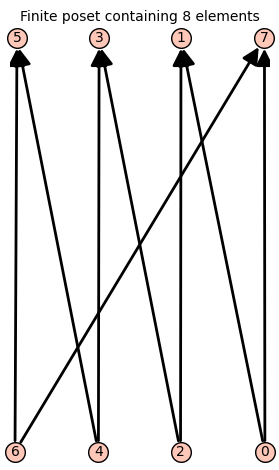

In [11]:
# Testing

# Build your own unicyclic poset
unicyclic_poset = Poset({
    0:[1,7],
    1:[],
    2:[1,3],
    3:[],
    4:[3,5],
    5:[],
    6:[5,7]
})

# Build the poset from the algorithm
Realiser = three_realiser(cycle_and_attached_trees(unicyclic_poset))
print(Realiser)

# Build the poset obtained from the three_realiser algorithm and test if it is isomorphic to unicyclic_poset
Poset_from_realiser = Poset(poset_from_linear_extensions(Realiser))
print(Poset_from_realiser.is_isomorphic(unicyclic_poset))

# And you can draw it
show(Poset_from_realiser)